# Routing Model — Valid (Microscopic) vs Invalid (Natural)

**Goal:** Binary classifier to route images.
- `valid` = microscopic medical images (chest X-ray: Normal + Pneumonia + TB)
- `invalid` = natural images (airplane, car, cat, dog, flower, fruit, motorbike, person)

**Design principles:**
- ~6800 valid images (balanced from 3 sources)
- All natural images as invalid
- Path-level split BEFORE copy → zero leakage
- Aggressive augmentation → generalization
- Custom CNN (lightweight, fast routing)
- Visualizations: train/val curves + confusion matrix

In [1]:
# ============================================================
# CELL 1 — Imports & Config
# ============================================================
import os, gc, random, shutil, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────
BASE_INPUT   = Path('/kaggle/input')
WORKING_DIR  = Path('/kaggle/working')
DATASET_DIR  = WORKING_DIR / 'routing_dataset'
ARTIFACT_DIR = WORKING_DIR / 'routing_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────
VALID_TARGET   = 6800   # total valid images
IMG_SIZE       = 128    # smaller = faster routing model
BATCH_SIZE     = 32
EPOCHS         = 30
PATIENCE       = 6
LR             = 1e-3
WEIGHT_DECAY   = 1e-4
NUM_CLASSES    = 2
CLASS_NAMES    = ['invalid', 'valid']   # 0=invalid, 1=valid

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Valid target: {VALID_TARGET} | IMG: {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE}')

Device: cuda
GPU: Tesla T4
Valid target: 6800 | IMG: 128x128 | Batch: 32


In [2]:
# ============================================================
# CELL 2 — Explore Input Folder Structure
# ============================================================
print('=== Kaggle Input Directories ===')
for p in sorted(BASE_INPUT.rglob('*')):
    if p.is_dir():
        # Count images
        imgs = [f for f in p.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS]
        if imgs:
            print(f'  {p}  [{len(imgs)} images]')
        else:
            print(f'  {p}/')

=== Kaggle Input Directories ===
  /kaggle/input/datasets/
  /kaggle/input/datasets/paultimothymooney/
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test/
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test/NORMAL  [234 images]
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA  [390 images]
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train/
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train/NORMAL  [1341 images]
  /k

In [3]:
# ============================================================
# CELL 3 — Locate Source Paths (Auto-detect)
# ============================================================

def find_dir(base: Path, keywords: list, must_contain_images=True) -> Path | None:
    """Find first directory matching ALL keywords in path string."""
    for p in sorted(base.rglob('*')):
        if not p.is_dir():
            continue
        path_str = str(p).lower()
        if all(kw.lower() in path_str for kw in keywords):
            if must_contain_images:
                imgs = [f for f in p.iterdir() if f.is_file()
                        and f.suffix.lower() in IMAGE_EXTENSIONS]
                if imgs:
                    return p
            else:
                return p
    return None

def collect_images(folder: Path) -> list:
    """Recursively collect all image paths from folder."""
    return [p for p in folder.rglob('*')
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]

# ── Pneumonia dataset paths ──────────────────────────────────
# Structure: chest_xray/chest_xray/{train,test,val}/{NORMAL,PNEUMONIA}
# We merge train+test+val to get all images, then do OUR OWN split

def find_pneumonia_class_dirs(base: Path, class_name: str) -> list:
    """Find all folders named class_name inside chest-xray dataset."""
    found = []
    for p in base.rglob(class_name):
        if p.is_dir():
            # Skip __MACOSX
            if '__MACOSX' not in str(p):
                found.append(p)
    return found

pneu_normal_dirs  = find_pneumonia_class_dirs(BASE_INPUT, 'NORMAL')
pneu_pneumonia_dirs = find_pneumonia_class_dirs(BASE_INPUT, 'PNEUMONIA')

print(f'Pneumonia dataset NORMAL  dirs : {len(pneu_normal_dirs)}')
for d in pneu_normal_dirs: print(f'   {d}')
print(f'Pneumonia dataset PNEUMONIA dirs: {len(pneu_pneumonia_dirs)}')
for d in pneu_pneumonia_dirs: print(f'   {d}')

Pneumonia dataset NORMAL  dirs : 6
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val/NORMAL
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL
Pneumonia dataset PNEUMONIA dirs: 6
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val/PNEUMONIA
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA
   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEU

In [4]:
# ── TB dataset paths ─────────────────────────────────────────
# Structure: TB_Chest_Radiography_Database/{Normal, Tuberculosis}

def find_tb_dirs(base: Path) -> dict:
    result = {}
    for name in ['Normal', 'Tuberculosis']:
        for p in base.rglob(name):
            if p.is_dir() and '__MACOSX' not in str(p):
                imgs = [f for f in p.iterdir() if f.is_file()
                        and f.suffix.lower() in IMAGE_EXTENSIONS]
                if imgs:
                    result[name] = p
                    break
    return result

tb_dirs = find_tb_dirs(BASE_INPUT)
print('TB dataset dirs:')
for k, v in tb_dirs.items():
    print(f'   {k}: {v}  [{len(collect_images(v))} images]')

TB dataset dirs:
   Normal: /kaggle/input/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/TB_Chest_Radiography_Database/Normal  [3500 images]
   Tuberculosis: /kaggle/input/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/TB_Chest_Radiography_Database/Tuberculosis  [700 images]


In [5]:
# ── Natural images paths ─────────────────────────────────────
# Structure: natural_images/{airplane,car,cat,dog,flower,fruit,motorbike,person}

NATURAL_CLASSES = ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']

def find_natural_dirs(base: Path) -> dict:
    result = {}
    for cls in NATURAL_CLASSES:
        for p in base.rglob(cls):
            if p.is_dir() and '__MACOSX' not in str(p):
                imgs = [f for f in p.iterdir() if f.is_file()
                        and f.suffix.lower() in IMAGE_EXTENSIONS]
                if imgs:
                    result[cls] = p
                    break
    return result

natural_dirs = find_natural_dirs(BASE_INPUT)
print('Natural image dirs:')
for k, v in natural_dirs.items():
    print(f'   {k}: {v}  [{len(collect_images(v))} images]')

Natural image dirs:
   airplane: /kaggle/input/datasets/prasunroy/natural-images/natural_images/airplane  [727 images]
   car: /kaggle/input/datasets/prasunroy/natural-images/natural_images/car  [968 images]
   cat: /kaggle/input/datasets/prasunroy/natural-images/natural_images/cat  [885 images]
   dog: /kaggle/input/datasets/prasunroy/natural-images/natural_images/dog  [702 images]
   flower: /kaggle/input/datasets/prasunroy/natural-images/natural_images/flower  [843 images]
   fruit: /kaggle/input/datasets/prasunroy/natural-images/natural_images/fruit  [1000 images]
   motorbike: /kaggle/input/datasets/prasunroy/natural-images/natural_images/motorbike  [788 images]
   person: /kaggle/input/datasets/prasunroy/natural-images/natural_images/person  [986 images]


In [6]:
# ============================================================
# CELL 4 — Collect & Balance Valid Images (~6800)
# ============================================================
# Sources for VALID class:
#   A) Pneumonia-dataset NORMAL    → ~1800 images
#   B) Pneumonia-dataset PNEUMONIA → ~5400 images
#   C) TB-dataset Normal           → ~3500 images
#   D) TB-dataset Tuberculosis     → ~700  images
#
# Strategy: proportional sampling to reach VALID_TARGET=6800
#   - normal_pneu  : 1700
#   - pneumonia    : 2200
#   - tb_normal    : 1700
#   - tb_disease   : 1200
#   Total          : 6800
#
# Adjust if actual counts are lower.

PER_SOURCE = {
    'normal_pneu' : 1700,
    'pneumonia'   : 2200,
    'tb_normal'   : 1700,
    'tb_disease'  : 1200,
}

random.seed(SEED)

def sample_images(dirs: list, n: int, prefix: str) -> list:
    """Collect all images from dirs, shuffle, return up to n paths with prefix tag."""
    all_imgs = []
    for d in dirs:
        all_imgs.extend(collect_images(d))
    random.shuffle(all_imgs)
    sampled = all_imgs[:n]
    return [(p, prefix) for p in sampled]

# Collect valid sources
valid_paths = []
valid_paths += sample_images(pneu_normal_dirs,   PER_SOURCE['normal_pneu'],  'pneu_normal')
valid_paths += sample_images(pneu_pneumonia_dirs, PER_SOURCE['pneumonia'],    'pneu_pneumonia')

tb_normal_imgs    = collect_images(tb_dirs['Normal'])       if 'Normal'      in tb_dirs else []
tb_disease_imgs   = collect_images(tb_dirs['Tuberculosis']) if 'Tuberculosis' in tb_dirs else []
random.shuffle(tb_normal_imgs);  random.shuffle(tb_disease_imgs)
valid_paths += [(p, 'tb_normal')  for p in tb_normal_imgs[:PER_SOURCE['tb_normal']]]
valid_paths += [(p, 'tb_disease') for p in tb_disease_imgs[:PER_SOURCE['tb_disease']]]

print(f'Total VALID paths collected: {len(valid_paths)}')
from collections import Counter
source_counts = Counter(src for _, src in valid_paths)
for src, cnt in source_counts.items():
    print(f'   {src}: {cnt}')

Total VALID paths collected: 6300
   pneu_normal: 1700
   pneu_pneumonia: 2200
   tb_normal: 1700
   tb_disease: 700


In [7]:
# ============================================================
# CELL 5 — Collect Invalid Images (all natural images)
# ============================================================
random.seed(SEED)

invalid_paths = []
for cls, d in natural_dirs.items():
    imgs = collect_images(d)
    invalid_paths += [(p, f'natural_{cls}') for p in imgs]

random.shuffle(invalid_paths)

print(f'Total INVALID paths collected: {len(invalid_paths)}')
invalid_counts = Counter(src for _, src in invalid_paths)
for src, cnt in invalid_counts.items():
    print(f'   {src}: {cnt}')

Total INVALID paths collected: 6899
   natural_car: 968
   natural_cat: 885
   natural_person: 986
   natural_flower: 843
   natural_airplane: 727
   natural_motorbike: 788
   natural_dog: 702
   natural_fruit: 1000


In [8]:
# ============================================================
# CELL 6 — PATH-LEVEL SPLIT (Zero Leakage)
# Split PATHS first, THEN copy files.
# This prevents same image appearing in train & val/test.
# ============================================================

# Build flat lists: (path, source_tag, label)
all_data = [(p, src, 1) for p, src in valid_paths] + \
           [(p, src, 0) for p, src in invalid_paths]

random.seed(SEED)
random.shuffle(all_data)

paths_only  = [str(item[0]) for item in all_data]
labels_only = [item[2]      for item in all_data]

# Stratified split: 80 train / 10 val / 10 test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths_only, labels_only,
    test_size=0.20,
    stratify=labels_only,
    random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

# Verify no overlap
train_set = set(train_paths)
val_set   = set(val_paths)
test_set  = set(test_paths)
assert len(train_set & val_set)  == 0, 'LEAKAGE: train/val overlap!'
assert len(train_set & test_set) == 0, 'LEAKAGE: train/test overlap!'
assert len(val_set   & test_set) == 0, 'LEAKAGE: val/test overlap!'

print('Zero leakage verified!')
print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')
print(f'Train valid={sum(train_labels)} invalid={len(train_labels)-sum(train_labels)}')
print(f'Val   valid={sum(val_labels)}   invalid={len(val_labels)-sum(val_labels)}')
print(f'Test  valid={sum(test_labels)}  invalid={len(test_labels)-sum(test_labels)}')

Zero leakage verified!
Train: 10559 | Val: 1320 | Test: 1320
Train valid=5040 invalid=5519
Val   valid=630   invalid=690
Test  valid=630  invalid=690


In [9]:
# ============================================================
# CELL 7 — Copy Files to Structured Dataset Folder
# routing_dataset/
#   train/valid/  train/invalid/
#   val/valid/    val/invalid/
#   test/valid/   test/invalid/
# ============================================================

for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        (DATASET_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def copy_split(paths, labels, split_name):
    copy_errors = 0
    for idx, (src_path, lbl) in enumerate(zip(paths, labels)):
        cls = CLASS_NAMES[lbl]
        src = Path(src_path)
        # Unique filename: splitN_label_originalname to avoid collisions
        dst_name = f'{split_name}{idx:06d}_{src.name}'
        dst = DATASET_DIR / split_name / cls / dst_name
        try:
            shutil.copy2(src, dst)
        except Exception as e:
            copy_errors += 1
            if copy_errors <= 3:
                print(f'  Copy error: {e}')
    return copy_errors

print('Copying train...')
err = copy_split(train_paths, train_labels, 'train')
print(f'  Done. Errors: {err}')

print('Copying val...')
err = copy_split(val_paths, val_labels, 'val')
print(f'  Done. Errors: {err}')

print('Copying test...')
err = copy_split(test_paths, test_labels, 'test')
print(f'  Done. Errors: {err}')

# Verify counts
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        n = len(list((DATASET_DIR / split / cls).iterdir()))
        print(f'  {split}/{cls}: {n}')

Copying train...
  Done. Errors: 0
Copying val...
  Done. Errors: 0
Copying test...
  Done. Errors: 0
  train/invalid: 5519
  train/valid: 5040
  val/invalid: 690
  val/valid: 630
  test/invalid: 690
  test/valid: 630


In [10]:
# ============================================================
# CELL 8 — Transforms (Augmentation for Train, Clean for Val/Test)
# ============================================================

# Medical images are grayscale → convert to RGB for consistency
# Heavy augmentation to handle domain gap between microscopic styles

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),        # some X-rays are grayscale
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print('Transforms defined.')

Transforms defined.


In [11]:
# ============================================================
# CELL 9 — Custom Dataset Class
# ============================================================

class RoutingDataset(Dataset):
    """Load images from folder structure: root/{class_name}/image.jpg"""

    def __init__(self, root: Path, transform=None):
        self.transform = transform
        self.samples   = []   # list of (path, label_int)
        self.classes   = CLASS_NAMES

        for lbl, cls in enumerate(self.classes):
            cls_dir = root / cls
            if not cls_dir.exists():
                print(f'WARNING: {cls_dir} not found')
                continue
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                    self.samples.append((img_path, lbl))

        random.shuffle(self.samples)
        print(f'Dataset loaded from {root}: {len(self.samples)} images')
        cnt = Counter(lbl for _, lbl in self.samples)
        for lbl, n in sorted(cnt.items()):
            print(f'   {CLASS_NAMES[lbl]}: {n}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=128)
        if self.transform:
            img = self.transform(img)
        return img, label

from collections import Counter

train_ds = RoutingDataset(DATASET_DIR / 'train', transform=train_transforms)
val_ds   = RoutingDataset(DATASET_DIR / 'val',   transform=eval_transforms)
test_ds  = RoutingDataset(DATASET_DIR / 'test',  transform=eval_transforms)

Dataset loaded from /kaggle/working/routing_dataset/train: 10559 images
   invalid: 5519
   valid: 5040
Dataset loaded from /kaggle/working/routing_dataset/val: 1320 images
   invalid: 690
   valid: 630
Dataset loaded from /kaggle/working/routing_dataset/test: 1320 images
   invalid: 690
   valid: 630


In [12]:
# ============================================================
# CELL 10 — DataLoaders
# ============================================================

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 330
Val   batches: 42
Test  batches: 42


In [13]:
# ============================================================
# CELL 11 — Custom CNN Architecture (RoutingNet)
# ============================================================
# Design philosophy:
#   - Lightweight (fast routing, not heavy classification)
#   - Depthwise separable conv blocks for efficiency
#   - Batch norm + dropout for regularization
#   - Squeeze-Excitation attention in deeper layers
#   - Global Average Pooling instead of flatten → param efficient

class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class DSConvBlock(nn.Module):
    """Depthwise Separable Conv + BN + ReLU."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                            padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU(inplace=True)   # Swish activation

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class ConvBnAct(nn.Module):
    """Standard Conv + BN + SiLU."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class RoutingNet(nn.Module):
    """
    Custom lightweight CNN for binary routing.
    Input: 3 x 128 x 128
    Output: 2 logits (invalid=0, valid=1)

    Architecture:
        Stem      : 3→32, 3x3, stride2   → 64x64
        Stage 1   : DSConv 32→64, stride2 → 32x32
        Stage 2   : DSConv 64→128, stride2 → 16x16  + SE
        Stage 3   : DSConv 128→256, stride2 → 8x8   + SE
        Stage 4   : DSConv 256→512, stride2 → 4x4   + SE
        Head      : GAP → 512 → Dropout(0.4) → 2
    """

    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()

        self.stem = ConvBnAct(3, 32, stride=2)       # 128→64

        self.stage1 = nn.Sequential(
            DSConvBlock(32,  64,  stride=2),          # 64→32
            ConvBnAct(64, 64),
        )

        self.stage2 = nn.Sequential(
            DSConvBlock(64,  128, stride=2),          # 32→16
            ConvBnAct(128, 128),
            SEBlock(128, reduction=8),
        )

        self.stage3 = nn.Sequential(
            DSConvBlock(128, 256, stride=2),          # 16→8
            ConvBnAct(256, 256),
            SEBlock(256, reduction=16),
        )

        self.stage4 = nn.Sequential(
            DSConvBlock(256, 512, stride=2),          # 8→4
            ConvBnAct(512, 512),
            SEBlock(512, reduction=16),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes)
        )

        # Weight init
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.head(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = RoutingNet(num_classes=NUM_CLASSES).to(device)
print(f'RoutingNet parameters: {count_params(model):,}')
print(model)

RoutingNet parameters: 3,362,690
RoutingNet(
  (stem): ConvBnAct(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
  )
  (stage1): Sequential(
    (0): DSConvBlock(
      (dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=32, bias=False)
      (pw): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): ConvBnAct(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
    )
  )
  (stage2): Sequential(
    (0): DSConvBlock(
      (dw): 

In [14]:
# ============================================================
# CELL 12 — Loss, Optimizer, Scheduler
# ============================================================

# Compute class weights to handle imbalance
train_label_list = [lbl for _, lbl in train_ds.samples]
train_counts = Counter(train_label_list)
total_train  = len(train_label_list)
class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * train_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)
print(f'Class weights: invalid={class_weights[0]:.3f}, valid={class_weights[1]:.3f}')

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing + warmup via OneCycleLR
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,          # 10% warmup
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=100.0
)

print('Optimizer, Scheduler, Loss ready.')

Class weights: invalid=0.957, valid=1.048
Optimizer, Scheduler, Loss ready.


In [15]:
# ============================================================
# CELL 13 — Training Loop
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds      = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


# History tracking
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc  = 0.0
best_epoch    = 0
patience_cnt  = 0
best_ckpt     = ARTIFACT_DIR / 'routing_best.pth'

print(f'Training RoutingNet for {EPOCHS} epochs...')
print(f'Early stop patience: {PATIENCE}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion,
                                    optimizer, scheduler, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    improved = v_acc > best_val_acc
    if improved:
        best_val_acc = v_acc
        best_epoch   = epoch
        patience_cnt = 0
        torch.save(model.state_dict(), best_ckpt)
        tag = '✓'
    else:
        patience_cnt += 1
        tag = ''

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'TLoss:{t_loss:.4f} TAcc:{t_acc:.4f} | '
          f'VLoss:{v_loss:.4f} VAcc:{v_acc:.4f} | '
          f'LR:{lr_now:.6f} {tag}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest Val Acc: {best_val_acc:.4f} at epoch {best_epoch}')

Training RoutingNet for 30 epochs...
Early stop patience: 6
-------------------------------------------------------
Epoch 01/30 | TLoss:0.1488 TAcc:0.9431 | VLoss:0.0073 VAcc:0.9970 | LR:0.000325 ✓
Epoch 02/30 | TLoss:0.0579 TAcc:0.9823 | VLoss:0.0057 VAcc:0.9970 | LR:0.000776 
Epoch 03/30 | TLoss:0.0478 TAcc:0.9841 | VLoss:0.0006 VAcc:1.0000 | LR:0.001000 ✓
Epoch 04/30 | TLoss:0.0310 TAcc:0.9904 | VLoss:0.0070 VAcc:0.9977 | LR:0.000997 
Epoch 05/30 | TLoss:0.0249 TAcc:0.9921 | VLoss:0.0023 VAcc:0.9992 | LR:0.000986 
Epoch 06/30 | TLoss:0.0185 TAcc:0.9935 | VLoss:0.0024 VAcc:0.9985 | LR:0.000970 
Epoch 07/30 | TLoss:0.0172 TAcc:0.9936 | VLoss:0.0003 VAcc:1.0000 | LR:0.000947 
Epoch 08/30 | TLoss:0.0142 TAcc:0.9955 | VLoss:0.0007 VAcc:1.0000 | LR:0.000918 
Epoch 09/30 | TLoss:0.0164 TAcc:0.9939 | VLoss:0.0010 VAcc:1.0000 | LR:0.000883 
Early stopping at epoch 9

Best Val Acc: 1.0000 at epoch 3


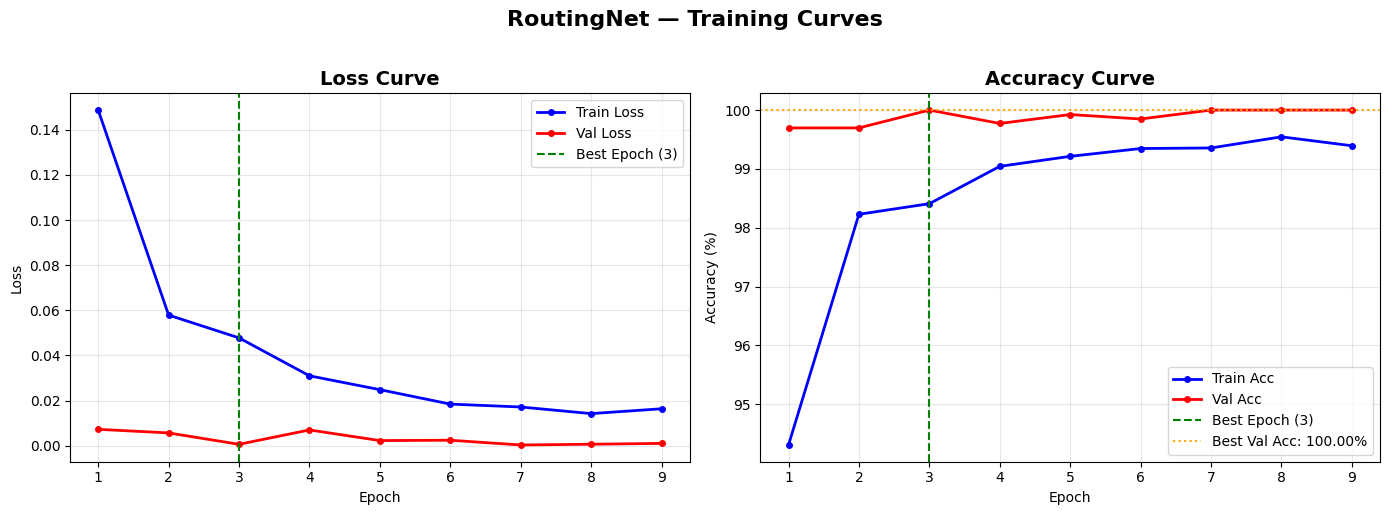

Training curves saved.


In [16]:
# ============================================================
# CELL 14 — Train vs Val Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss',
             linewidth=2, markersize=4)
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss',
             linewidth=2, markersize=4)
axes[0].axvline(best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, [a * 100 for a in history['train_acc']],
             'b-o', label='Train Acc', linewidth=2, markersize=4)
axes[1].plot(epochs_ran, [a * 100 for a in history['val_acc']],
             'r-o', label='Val Acc', linewidth=2, markersize=4)
axes[1].axvline(best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].axhline(best_val_acc * 100, color='orange', linestyle=':',
                label=f'Best Val Acc: {best_val_acc*100:.2f}%')
axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RoutingNet — Training Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

In [17]:
# ============================================================
# CELL 15 — Test Evaluation & Confusion Matrix
# ============================================================

# Load best weights
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

all_preds, all_labels = [], []
all_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        outputs = model(imgs)
        probs   = F.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))

Test Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

     invalid     1.0000    1.0000    1.0000       690
       valid     1.0000    1.0000    1.0000       630

    accuracy                         1.0000      1320
   macro avg     1.0000    1.0000    1.0000      1320
weighted avg     1.0000    1.0000    1.0000      1320



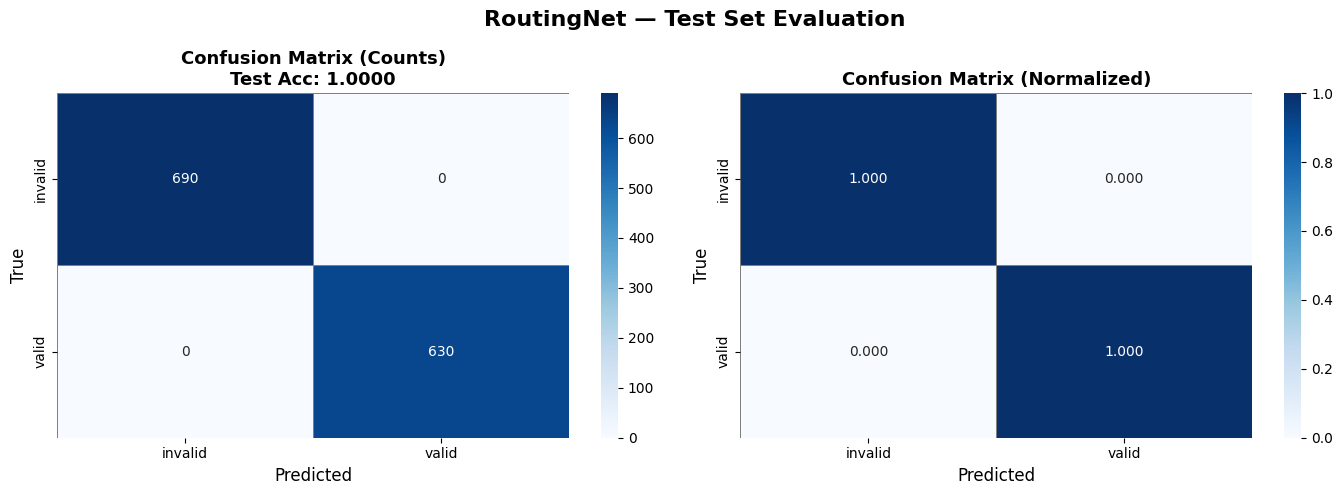

Confusion matrix saved.


In [18]:
# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title(f'Confusion Matrix (Counts)\nTest Acc: {test_acc:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)

# Normalized (row-wise)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)

plt.suptitle('RoutingNet — Test Set Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

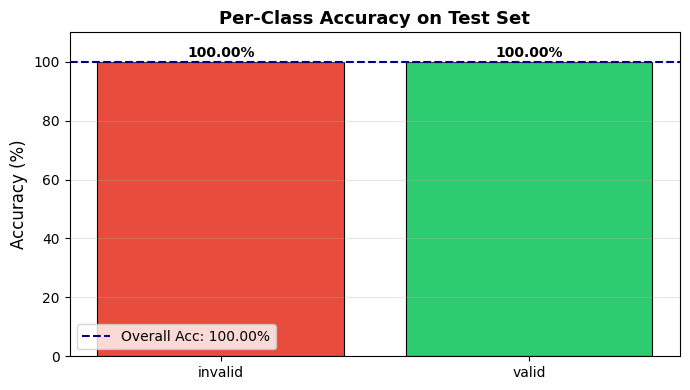

In [19]:
# ============================================================
# CELL 16 — Per-Class Accuracy Bar Chart
# ============================================================

per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, per_class_acc * 100,
              color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy on Test Set', fontsize=13, fontweight='bold')
ax.axhline(test_acc * 100, color='navy', linestyle='--',
           label=f'Overall Acc: {test_acc*100:.2f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'per_class_accuracy.png', dpi=150)
plt.show()

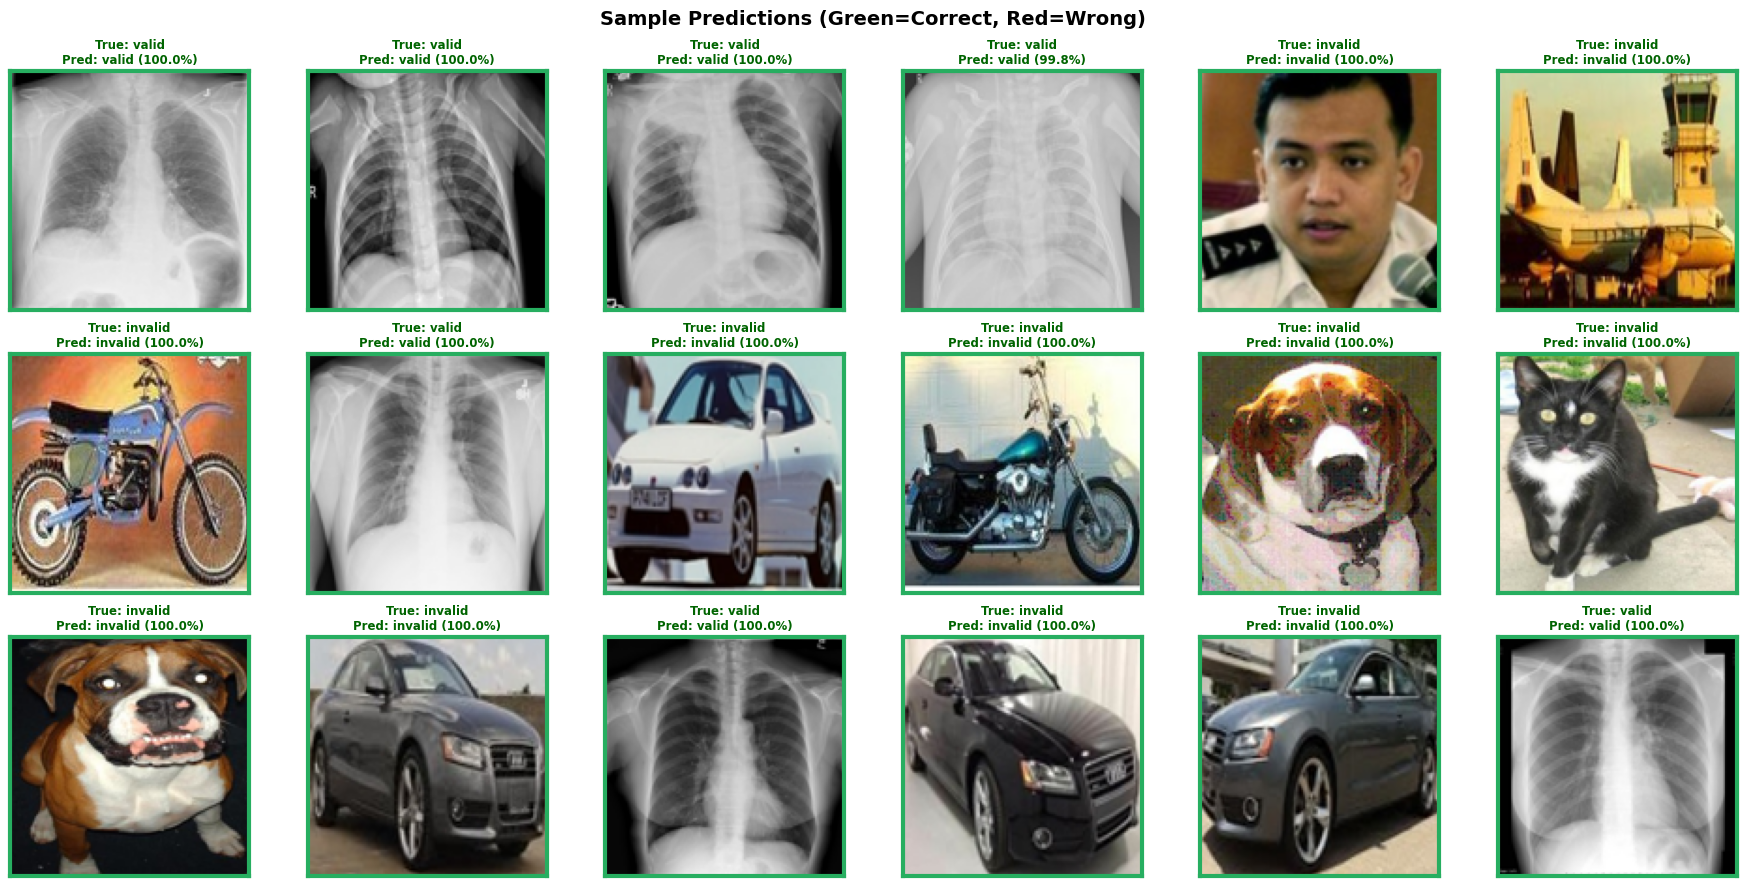

Sample predictions saved.


In [20]:
# ============================================================
# CELL 17 — Sample Predictions Visualization
# ============================================================

model.eval()
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

sample_indices = random.sample(range(len(test_ds)), 18)

for i, idx in enumerate(sample_indices):
    path, true_lbl = test_ds.samples[idx]
    img_pil = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    inp = eval_transforms(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        out   = model(inp)
        prob  = F.softmax(out, dim=1)
        pred  = out.argmax(1).item()
        conf  = prob[0, pred].item()

    correct = (pred == true_lbl)
    border_color = '#27ae60' if correct else '#e74c3c'

    ax = axes[i]
    ax.imshow(img_pil)
    ax.set_title(
        f"True: {CLASS_NAMES[true_lbl]}\nPred: {CLASS_NAMES[pred]} ({conf*100:.1f}%)",
        fontsize=8.5,
        color='darkgreen' if correct else 'darkred',
        fontweight='bold'
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'sample_predictions.png', dpi=150)
plt.show()
print('Sample predictions saved.')

In [21]:
# ============================================================
# CELL 18 — Final Summary & Model Download Info
# ============================================================
import json

from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted', zero_division=0
)

summary = {
    'model'             : 'RoutingNet',
    'task'              : 'valid_vs_invalid_binary',
    'img_size'          : IMG_SIZE,
    'num_params'        : count_params(model),
    'total_images'      : len(train_ds) + len(val_ds) + len(test_ds),
    'train_images'      : len(train_ds),
    'val_images'        : len(val_ds),
    'test_images'       : len(test_ds),
    'best_epoch'        : best_epoch,
    'best_val_acc'      : round(best_val_acc, 6),
    'test_acc'          : round(test_acc, 6),
    'precision_weighted': round(float(prec), 6),
    'recall_weighted'   : round(float(rec),  6),
    'f1_weighted'       : round(float(f1),   6),
    'valid_sources'     : list(source_counts.keys()),
    'invalid_sources'   : NATURAL_CLASSES,
    'class_names'       : CLASS_NAMES,
    'checkpoint'        : str(best_ckpt),
}

with open(ARTIFACT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 60)
print('  ROUTINGNET — FINAL SUMMARY')
print('=' * 60)
for k, v in summary.items():
    print(f'  {k:25s}: {v}')
print('=' * 60)
print()
print('Artifacts saved to:', ARTIFACT_DIR)
print()
print('Files in artifact dir:')
for f in sorted(ARTIFACT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'   {f.name:40s}  {size_mb:.2f} MB')
print()
print('To download the model, the .pth file is: routing_best.pth')
print('Load with:')
print('   model = RoutingNet(num_classes=2)')
print('   model.load_state_dict(torch.load("routing_best.pth", map_location="cpu"))')
print('   model.eval()')

  ROUTINGNET — FINAL SUMMARY
  model                    : RoutingNet
  task                     : valid_vs_invalid_binary
  img_size                 : 128
  num_params               : 3362690
  total_images             : 13199
  train_images             : 10559
  val_images               : 1320
  test_images              : 1320
  best_epoch               : 3
  best_val_acc             : 1.0
  test_acc                 : 1.0
  precision_weighted       : 1.0
  recall_weighted          : 1.0
  f1_weighted              : 1.0
  valid_sources            : ['pneu_normal', 'pneu_pneumonia', 'tb_normal', 'tb_disease']
  invalid_sources          : ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
  class_names              : ['invalid', 'valid']
  checkpoint               : /kaggle/working/routing_artifacts/routing_best.pth

Artifacts saved to: /kaggle/working/routing_artifacts

Files in artifact dir:
   confusion_matrix.png                      0.07 MB
   per_class_accu